# Task 3 — Used Car Price Prediction: EDA, Cleaning & Feature Engineering
**Epochs '26 — Assignment 3**

Dataset: [Used Car Price Prediction Dataset](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset)

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Data Cleaning
3. Feature Engineering
4. Saving the cleaned dataset for future model building


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('used_cars.csv')   # <-- rename to match your downloaded file
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Part 1: Exploratory Data Analysis (EDA)

### 1.1 Basic structure

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (4009, 12)
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


### 1.2 Numerical vs categorical features

In [3]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['model_year']
Categorical columns: ['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


/tmp/ipykernel_547/2981587766.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


Note: `milage` and `price` usually load as text (e.g. `"51,000 mi."`, `"$10,300"`) because of
symbols/commas, so they'll initially show up as categorical/object even though they're really numeric.
We'll fix that in the cleaning section.

### 1.3 Descriptive statistics

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,4009.0,NaN,NaN,NaN,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009,2818,"110,000 mi.",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,3839,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident,3896,2,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Missing values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
clean_title,596,14.866550
fuel_type,170,4.240459
accident,113,2.818658


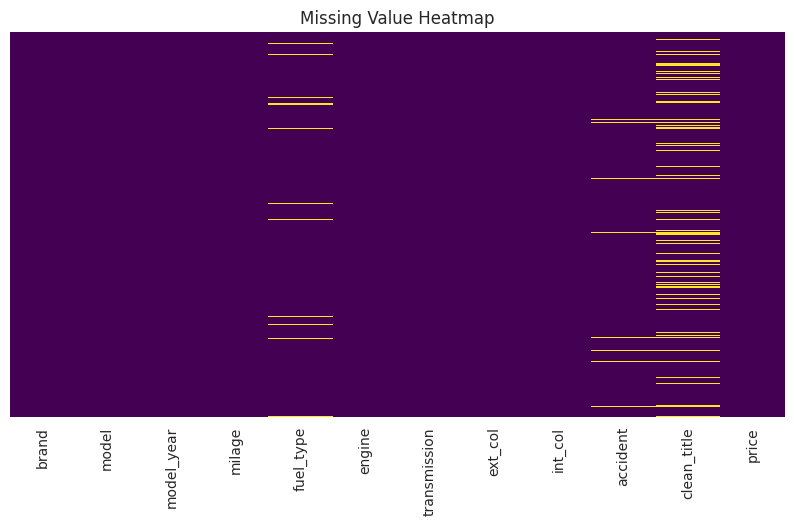

In [6]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

### 1.5 Duplicate records

In [7]:
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")

Number of duplicate rows: 0


### 1.6 Unique values & distributions of categorical features

In [8]:
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))


brand: 57 unique values
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Name: count, dtype: int64

model: 1898 unique values
model
M3 Base               30
F-150 XLT             24
Corvette Base         22
1500 Laramie          18
Model Y Long Range    17
Camaro 2SS            17
Wrangler Sport        17
Mustang GT Premium    16
911 Carrera           16
M4 Base               15
Name: count, dtype: int64

milage: 2818 unique values
milage
110,000 mi.    16
45,000 mi.     15
120,000 mi.    13
55,000 mi.     13
54,000 mi.     12
60,000 mi.     12
40,000 mi.     12
65,000 mi.     12
92,000 mi.     12
74,000 mi.     11
Name: count, dtype: int64

fuel_type: 7 unique values
fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not sup

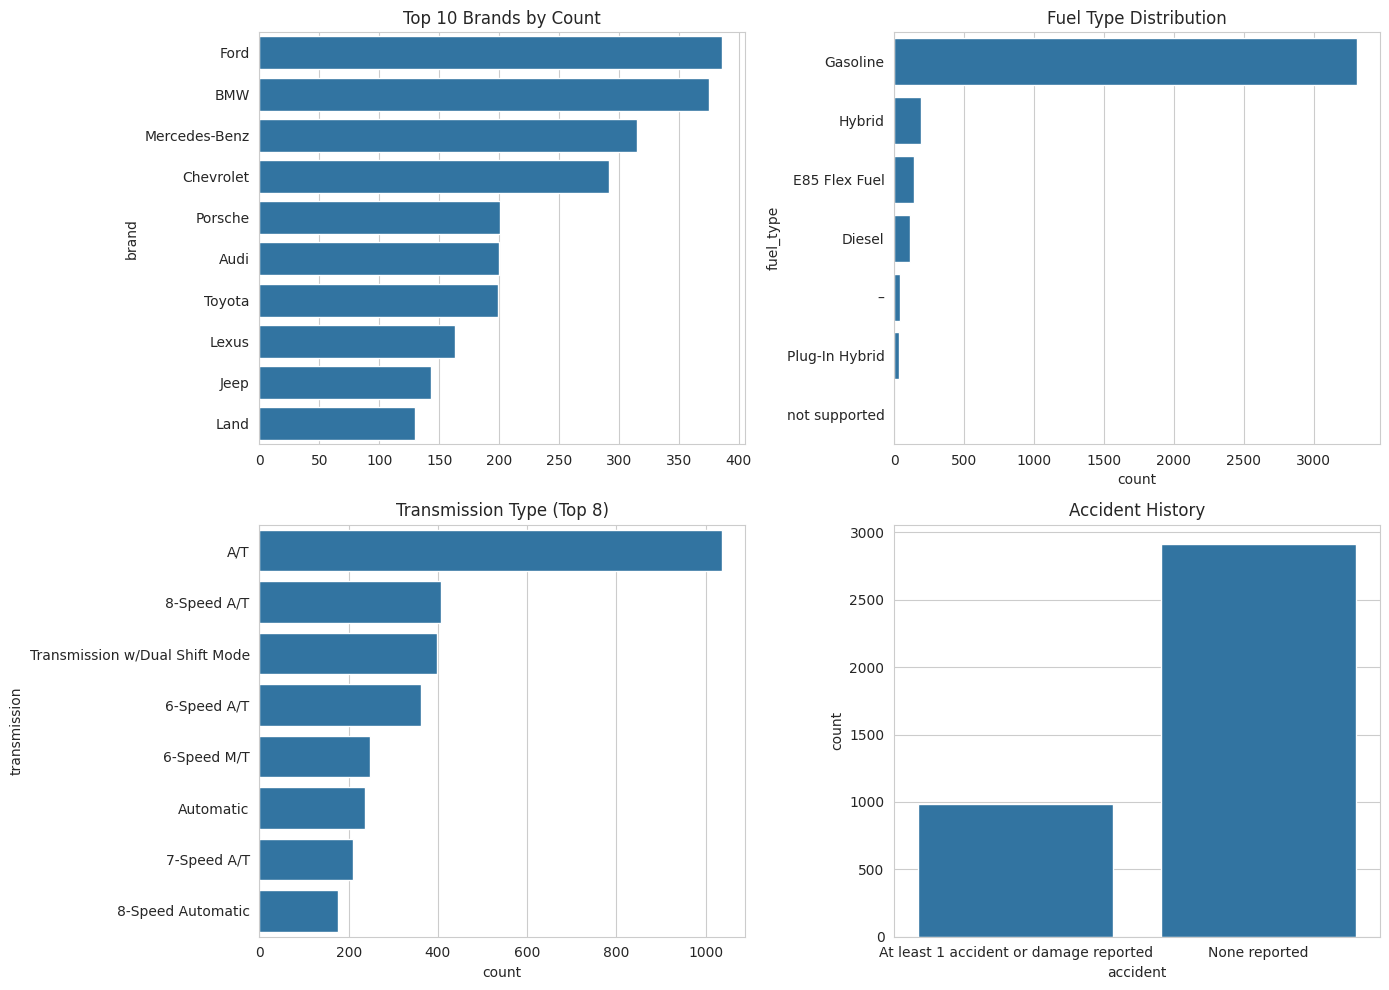

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
top_brands = df['brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[0,0])
axes[0,0].set_title('Top 10 Brands by Count')

sns.countplot(y='fuel_type', data=df, order=df['fuel_type'].value_counts().index, ax=axes[0,1])
axes[0,1].set_title('Fuel Type Distribution')

sns.countplot(y='transmission', data=df,
              order=df['transmission'].value_counts().head(8).index, ax=axes[1,0])
axes[1,0].set_title('Transmission Type (Top 8)')

sns.countplot(x='accident', data=df, ax=axes[1,1])
axes[1,1].set_title('Accident History')

plt.tight_layout()
plt.show()

### 1.7 Distributions of numerical features (model_year, mileage, price)

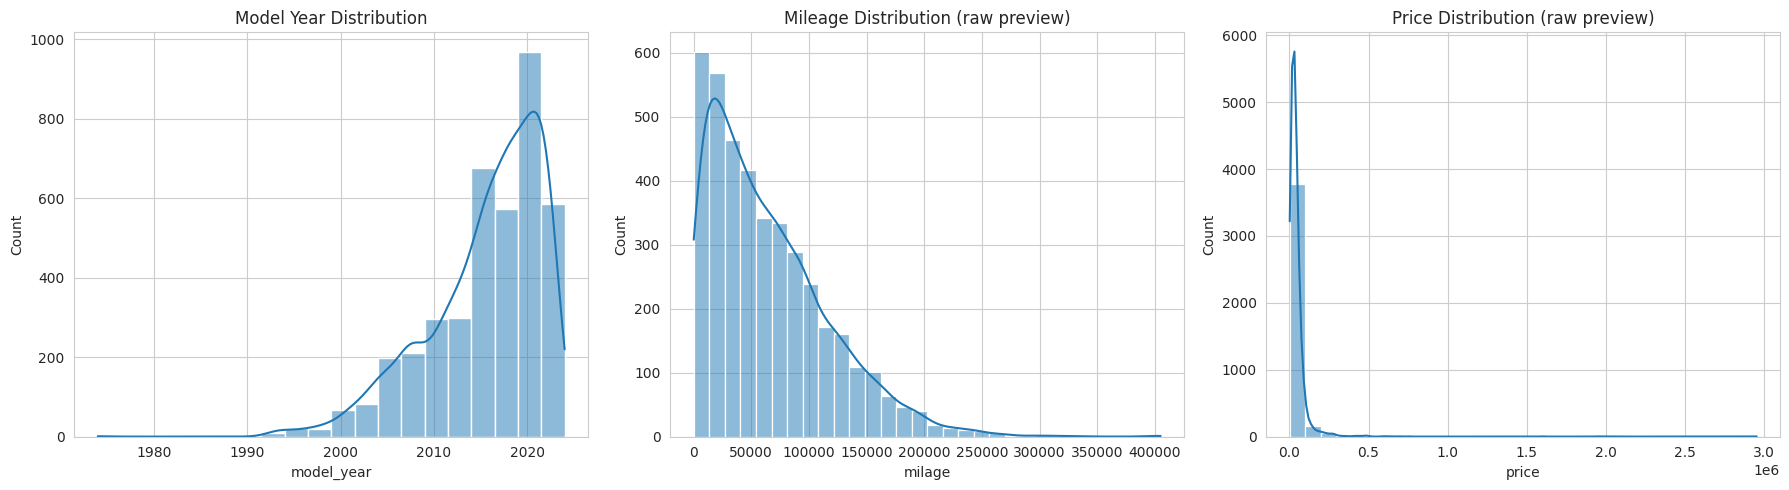

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['model_year'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Model Year Distribution')

# milage/price need string cleaning first for accurate plotting -- see Part 2
# quick preview using a temporary numeric conversion:
temp_mileage = df['milage'].astype(str).str.replace(r'[^0-9]', '', regex=True).astype(float)
temp_price = df['price'].astype(str).str.replace(r'[^0-9]', '', regex=True).astype(float)

sns.histplot(temp_mileage, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Mileage Distribution (raw preview)')

sns.histplot(temp_price, bins=30, kde=True, ax=axes[2])
axes[2].set_title('Price Distribution (raw preview)')

plt.tight_layout()
plt.show()

### 1.8 Outlier detection (boxplots + IQR)

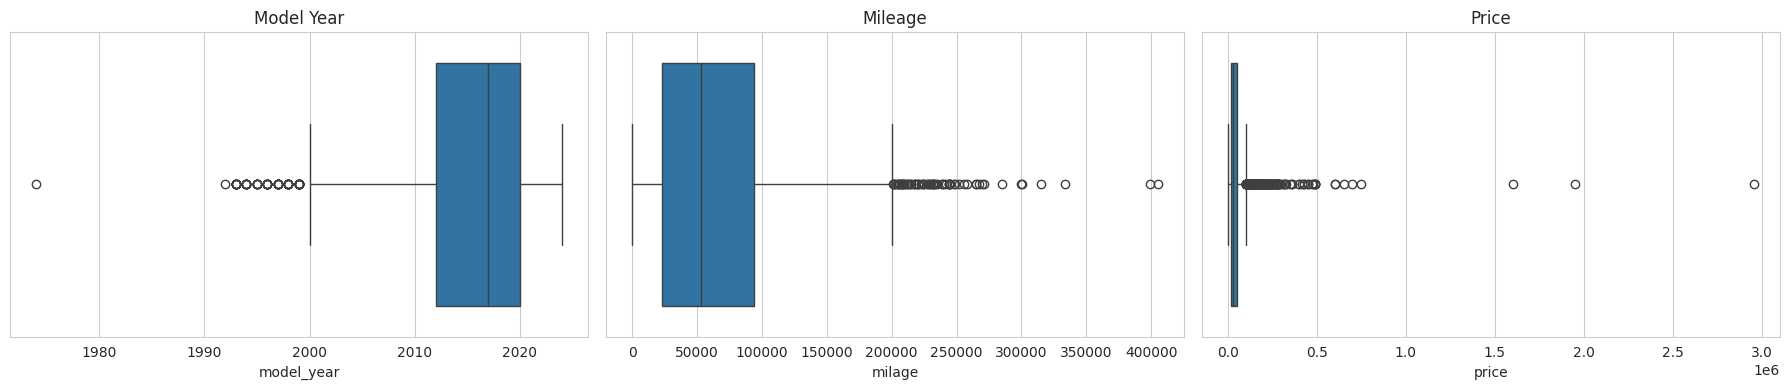

model_year: bounds=(2000.0, 2032.0), outliers=67
mileage: bounds=(-83540.0, 200684.0), outliers=69
price: bounds=(-31985.0, 99175.0), outliers=244


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(x=df['model_year'], ax=axes[0]); axes[0].set_title('Model Year')
sns.boxplot(x=temp_mileage, ax=axes[1]); axes[1].set_title('Mileage')
sns.boxplot(x=temp_price, ax=axes[2]); axes[2].set_title('Price')
plt.tight_layout()
plt.show()

def iqr_outlier_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for name, series in [('model_year', df['model_year']), ('mileage', temp_mileage), ('price', temp_price)]:
    low, high = iqr_outlier_bounds(series)
    n_outliers = ((series < low) | (series > high)).sum()
    print(f"{name}: bounds=({low:.1f}, {high:.1f}), outliers={n_outliers}")

**Outlier handling approach:** rather than dropping rows outright (which loses data), we cap
(winsorize) extreme `price` and `milage` values at the IQR bounds in Part 2 — this keeps every
record while limiting the influence of extreme values on a future model.

### 1.9 Key Insights

1. **Missing data is concentrated in 3 columns:** `clean_title` is missing for 596 rows (~14.9%), `accident` for 113 rows (~2.8%), and `fuel_type` for 170 rows (~4.2%) — all other columns are complete.
2. **Most listings are 2012–2020 model years** (25th–75th percentile), with the full range spanning 1974–2024, so a handful of much older cars pull the range wide.
3. **Ford, BMW, Mercedes-Benz, Chevrolet, and Porsche are the top 5 brands** by listing count, with Ford leading at 386 listings.
4. **Price is heavily right-skewed** (skewness ≈ 19.5): median price is $31,000 but the mean is pulled up to ~$44,550 by a long tail of luxury/exotic listings running into the millions (max ~$2.95M). The IQR method flags 244 price outliers and 69 mileage outliers.
5. **Accident history is linked to lower price:** cars with a reported accident average ~$28,832, versus ~$49,681 for cars with no reported accident — roughly a 42% price gap.


## Part 2: Data Cleaning & Feature Engineering

### 2.1 Copy the dataframe for cleaning

In [12]:
df_clean = df.copy()

### 2.2 Fix data types: clean `milage` and `price` into numeric columns

In [13]:
df_clean['milage'] = (
    df_clean['milage'].astype(str)
    .str.replace(r'[^0-9]', '', regex=True)
    .astype(float)
)

df_clean['price'] = (
    df_clean['price'].astype(str)
    .str.replace(r'[^0-9]', '', regex=True)
    .astype(float)
)

df_clean[['milage', 'price']].describe()

,milage,price
count,4009.000000,4.009000e+03
mean,64717.551010,4.455319e+04
std,52296.599459,7.871064e+04
min,100.000000,2.000000e+03
25%,23044.000000,1.720000e+04
50%,52775.000000,3.100000e+04
75%,94100.000000,4.999000e+04
max,405000.000000,2.954083e+06


### 2.3 Handle missing values

In [14]:
# Categorical: fill with 'Unknown' (safer than dropping rows for a small dataset)
for col in ['fuel_type', 'accident', 'clean_title']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

# Numerical: fill any missing with the median (robust to outliers)
for col in ['model_year', 'milage', 'price']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

### 2.4 Remove duplicate records

In [15]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed {before - after} duplicate rows")

Removed 0 duplicate rows


### 2.5 Handle outliers (cap using IQR bounds)

In [16]:
def cap_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series.clip(lower=low, upper=high)

df_clean['price'] = cap_outliers(df_clean['price'])
df_clean['milage'] = cap_outliers(df_clean['milage'])

df_clean[['price', 'milage']].describe()

,price,milage
count,4009.000000,4009.000000
mean,37514.270392,64071.666750
std,25986.581650,50074.537745
min,2000.000000,100.000000
25%,17200.000000,23044.000000
50%,31000.000000,52775.000000
75%,49990.000000,94100.000000
max,99175.000000,200684.000000


### 2.6 Feature Engineering (5+ new features)

In [17]:
current_year = 2026

# 1. car_age -- how old the car is
df_clean['car_age'] = current_year - df_clean['model_year']

# 2. mileage_per_year -- usage intensity, normalizes mileage by age
df_clean['mileage_per_year'] = df_clean['milage'] / df_clean['car_age'].replace(0, 1)

# 3. is_luxury_brand -- flag common luxury brands
luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Porsche', 'Jaguar', 'Land Rover', 'Bentley', 'Ferrari', 'Maserati']
df_clean['is_luxury_brand'] = df_clean['brand'].isin(luxury_brands).astype(int)

# 4. had_accident -- binary flag from the accident text column
df_clean['had_accident'] = df_clean['accident'].astype(str).str.contains(
    'accident', case=False, na=False
).astype(int)

# 5. has_clean_title -- binary flag
df_clean['has_clean_title'] = (df_clean['clean_title'].astype(str).str.lower() == 'yes').astype(int)

# 6. engine_size_l -- extract liters from the engine text (e.g. "3.5L V6")
df_clean['engine_size_l'] = df_clean['engine'].astype(str).str.extract(r'(\d+\.\d+)L').astype(float)

# 7. is_automatic -- transmission simplified to binary
df_clean['is_automatic'] = df_clean['transmission'].astype(str).str.contains(
    'automatic|a/t|cvt', case=False, na=False
).astype(int)

df_clean[['car_age', 'mileage_per_year', 'is_luxury_brand', 'had_accident',
          'has_clean_title', 'engine_size_l', 'is_automatic']].head()

,car_age,mileage_per_year,is_luxury_brand,had_accident,has_clean_title,engine_size_l,is_automatic
0,13,3923.076923,0,1,1,3.7,1
1,5,6948.400000,0,1,1,3.8,1
2,4,5593.000000,1,0,0,NaN,1
3,11,8081.818182,0,0,1,3.5,1
4,5,1967.000000,1,0,0,2.0,1


### 2.7 Final check before saving

In [18]:
print("Final shape:", df_clean.shape)
df_clean.info()
df_clean.head()

Final shape: (4009, 19)
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             4009 non-null   str    
 1   model             4009 non-null   str    
 2   model_year        4009 non-null   int64  
 3   milage            4009 non-null   float64
 4   fuel_type         4009 non-null   str    
 5   engine            4009 non-null   str    
 6   transmission      4009 non-null   str    
 7   ext_col           4009 non-null   str    
 8   int_col           4009 non-null   str    
 9   accident          4009 non-null   str    
 10  clean_title       4009 non-null   str    
 11  price             4009 non-null   float64
 12  car_age           4009 non-null   int64  
 13  mileage_per_year  4009 non-null   float64
 14  is_luxury_brand   4009 non-null   int64  
 15  had_accident      4009 non-null   int64  
 16  has_clean_title   4009 non-nu

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,mileage_per_year,is_luxury_brand,had_accident,has_clean_title,engine_size_l,is_automatic
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13,3923.076923,0,1,1,3.7,1
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5,6948.400000,0,1,1,3.8,1
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0,4,5593.000000,1,0,0,NaN,1
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11,8081.818182,0,0,1,3.5,1
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0,5,1967.000000,1,0,0,2.0,1


### 2.8 Save the cleaned dataset

In [19]:
df_clean.to_csv('cleaned_used_cars.csv', index=False)
print("Saved cleaned_used_cars.csv")

Saved cleaned_used_cars.csv


---
## Next steps (for the README)
- Fill in the 5 key insights in section 1.9 above with your actual numbers.
- Summarize cleaning techniques applied and features engineered in `README.md`.
